In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('crawl_results_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        24720 non-null  object
 1   price        24720 non-null  object
 2   posted_date  24720 non-null  object
 3   specs        24720 non-null  object
dtypes: object(4)
memory usage: 772.6+ KB


In [228]:
import pandas as pd
import ast

df["specs"] = df["specs"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
specs_df = df["specs"].apply(pd.Series)
df = pd.concat([df[["title", "price", "posted_date"]], specs_df], axis=1)
df.head()

,title,price,posted_date,Năm sản xuất,Tình trạng,Số Km đã đi,Xuất xứ,Kiểu dáng,Hộp số,Động cơ
0,Xe Audi A6 2.0 TFSI 2014,499 Triệu,1/10/2025,2014,Xe đã dùng,"68,000 Km",Nhập khẩu,Sedan,Số tự động,Xăng 2.0 L
1,Xe BMW X4 xDrive20i M Sport 2020,1 Tỷ 750 Triệu,30/09/2025,2020,Xe đã dùng,"40,000 Km",Nhập khẩu,SUV,Số tự động,Xăng 2.0 L
2,Xe BMW X6 xDrive35i 2008,450 Triệu,1/10/2025,2008,Xe đã dùng,0 Km,Nhập khẩu,SUV,Số tự động,Xăng 3.0 L
3,Xe Ford Territory Titanium 1.5 AT 2022,735 Triệu,30/09/2025,2022,Xe đã dùng,"55,000 Km",Lắp ráp trong nước,SUV,Số tự động,Xăng 1.5 L
4,Xe Kia Morning Si AT 2015,248 Triệu,1/10/2025,2015,Xe đã dùng,"70,000 Km",Lắp ráp trong nước,Hatchback,Số tự động,Xăng 1.25 L


In [229]:
brand = set(df["title"].astype(str).apply(lambda x: x.split()[1] if len(x.split()) > 1 else None))
print(brand)

{'Hummer', 'Lynk', 'Toyota', 'Mercedes', 'Mazda', 'Lexus', 'Honda', 'Zotye', 'Volvo', 'Mitsubishi', 'Mooc', 'Kenbo', 'Omoda', 'Jeep', 'Ssangyong', 'Hino', 'Ferrari', 'Infiniti', 'Maybach', 'GMC', 'Nissan', 'Chrysler', 'Subaru', 'BYD', 'SRM', 'Peugeot', 'Luxgen', 'Lamborghini', 'Scion', 'Cadillac', 'MG', 'Volkswagen', 'Tata', 'SYM', 'Mekong', 'JMC', 'Changan', 'Samsung', 'Teraco', 'Bentley', 'Thaco', 'JRD', 'Maserati', 'RAM', 'LandRover', 'Jaguar', 'Smart', 'Porsche', 'Tobe', 'Suzuki', 'Vinaxuki', 'Kia', 'Isuzu', 'Gaz', 'Daihatsu', 'McLaren', 'Ford', 'Rolls', 'Iveco', 'Lincoln', 'Chevrolet', 'Dongben', 'Baic', 'Universe', 'Audi', 'Hyundai', 'Morgan', 'BMW', 'VinFast', 'Dodge', 'Geely', 'Mini', 'Renault', 'Aston', 'Veam', 'Hongqi', 'Citroen', 'Wuling', 'Daewoo', 'Acura', 'Fiat'}


In [230]:
import re
brands = [b.lower() for b in ['Hummer', 'Lynk', 'Toyota', 'Mercedes', 'Mazda', 'Lexus', 'Honda', 
    'Zotye', 'Volvo', 'Mitsubishi', 'Mooc', 'Kenbo', 'Omoda', 'Jeep', 'Ssangyong', 'Hino', 'Ferrari',
    'Infiniti', 'Maybach', 'GMC', 'Nissan', 'Chrysler', 'Subaru', 'BYD', 'SRM', 'Peugeot', 'Luxgen',
    'Lamborghini', 'Scion', 'Cadillac', 'MG', 'Volkswagen', 'Tata', 'SYM', 'Mekong', 'JMC', 'Changan',
    'Samsung', 'Teraco', 'Bentley', 'Thaco', 'JRD', 'Maserati', 'RAM', 'LandRover', 'Jaguar', 'Smart',
    'Porsche', 'Tobe', 'Suzuki', 'Vinaxuki', 'Kia', 'Isuzu', 'Gaz', 'Daihatsu', 'McLaren', 'Ford', 
    'Rolls', 'Iveco', 'Lincoln', 'Chevrolet', 'Dongben', 'Baic', 'Universe', 'Audi', 'Hyundai', 
    'Morgan', 'BMW', 'VinFast', 'Dodge', 'Geely', 'Mini', 'Renault', 'Aston', 'Veam', 'Hongqi', 
    'Citroen', 'Wuling', 'Daewoo', 'Acura', 'Fiat']]
def convert_price_to_number(price_str):
    if(type(price_str) == int or type(price_str) == float):
        return price_str
    if pd.isna(price_str):
        return np.nan
    
    price_str = str(price_str).lower()
    
    if 'tỷ' in price_str:
        parts = re.findall(r'\d+', price_str)
        if len(parts) >= 2:
            return int(parts[0]) * 1000 + int(parts[1])
        return int(parts[0]) * 1000 
    elif 'triệu' in price_str:
        parts = re.findall(r'\d+', price_str)
        return int(parts[0])
    
    return np.nan

def convert_km_to_number(km_str):
    if pd.isna(km_str):
        return np.nan
    
    km_str = str(km_str).replace(',', '').replace('Km', '').replace('km', '').strip()
    try:
        return int(km_str)
    except:
        return np.nan
    
def extract_engine_capacity(engine_str):
    if pd.isna(engine_str):
        return np.nan
    
    match = re.search(r'(\d+\.?\d*)\s*L', str(engine_str))
    if match:
        return float(match.group(1))
    return np.nan
    
def extract_engine_type(engine_str):
    if pd.isna(engine_str):
        return np.nan
    
    engine_str = str(engine_str).lower()
    engine_type = engine_str.split()[0]		
    if engine_type in ['xăng', 'dầu', 'điện', 'hybrid']:
        return engine_type
    return np.nan
def extract_brand_model(title):
    parts = str(title).strip().lower().split()
    if len(parts) < 2:
        return pd.Series([None, None])
    brand_key = parts[1].lower()
    if brand_key == "lynk":
        brand = "lynk & co"
    elif brand_key == "srm":
        brand = "dongben"
    elif brand_key in brands:
        brand = parts[1]
    else:
        brand = None  

    if brand:
        model = " ".join(parts[2:]) if len(parts) > 2 else None
    else:
        model = " ".join(parts[1:]) if len(parts) > 1 else None

    return pd.Series([brand, model])

data_clean = pd.DataFrame()
data_clean[['Hãng xe', 'Dòng xe']] = df['title'].apply(extract_brand_model)
data_clean['Giá thành'] = df['price'].apply(convert_price_to_number)
data_clean['Năm sản xuất'] = pd.to_numeric(df['Năm sản xuất'], errors='coerce')
data_clean['Số Km đã đi'] = df['Số Km đã đi'].apply(convert_km_to_number)
data_clean['Dung tích động cơ'] = df['Động cơ'].apply(extract_engine_capacity).apply(lambda x: str(x).lower())
data_clean['Loại động cơ'] = df['Động cơ'].apply(extract_engine_type).apply(lambda x: str(x).lower())
data_clean['Hộp số'] = df['Hộp số'].apply(lambda x: str(x).lower())
data_clean['Xuất xứ'] = df['Xuất xứ'].apply(lambda x: str(x).lower())
data_clean['Kiểu dáng'] = df['Kiểu dáng'].apply(lambda x: str(x).lower())
data_clean["Số ngày bài đã đăng"] = (pd.Timestamp.now() - pd.to_datetime(df["posted_date"], format="%d/%m/%Y", errors="coerce")).dt.days
print(data_clean.head())

  Hãng xe                         Dòng xe  Giá thành  Năm sản xuất  \
0    audi                a6 2.0 tfsi 2014        499          2014   
1     bmw       x4 xdrive20i m sport 2020       1750          2020   
2     bmw               x6 xdrive35i 2008        450          2008   
3    ford  territory titanium 1.5 at 2022        735          2022   
4     kia              morning si at 2015        248          2015   

   Số Km đã đi Dung tích động cơ Loại động cơ      Hộp số             Xuất xứ  \
0        68000               2.0         xăng  số tự động           nhập khẩu   
1        40000               2.0         xăng  số tự động           nhập khẩu   
2            0               3.0         xăng  số tự động           nhập khẩu   
3        55000               1.5         xăng  số tự động  lắp ráp trong nước   
4        70000              1.25         xăng  số tự động  lắp ráp trong nước   

   Kiểu dáng  Số ngày bài đã đăng  
0      sedan                   31  
1        suv        

In [231]:
from sklearn.impute import SimpleImputer
categorical_cols = ["Hãng xe", "Dòng xe", "Xuất xứ", "Kiểu dáng", "Hộp số", "Loại động cơ"]
numeric_cols = ["Năm sản xuất", "Số Km đã đi", "Số ngày bài đã đăng", "Dung tích động cơ"]
data_clean['Số Km đã đi'] = data_clean['Số Km đã đi'].replace(0, np.nan)

# Fill NaN
print("NaN trước khi fill:\n", data_clean.isna().sum()[data_clean.isna().sum() > 0])
data_clean[categorical_cols] = data_clean[categorical_cols].fillna("unknown")
imputer = SimpleImputer(strategy="mean")
data_clean[numeric_cols] = imputer.fit_transform(data_clean[numeric_cols])
print("\nNaN sau khi fill:\n", data_clean.isna().sum()[data_clean.isna().sum() > 0])

NaN trước khi fill:
 Số Km đã đi    2773
dtype: int64

NaN sau khi fill:
 Series([], dtype: int64)


In [232]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
data_clean = remove_outliers_iqr(data_clean, 'Giá thành')
data_clean = remove_outliers_iqr(data_clean, 'Số Km đã đi')
data_clean = remove_outliers_iqr(data_clean, 'Số ngày bài đã đăng')
data_clean = remove_outliers_iqr(data_clean, "Năm sản xuất")
data_clean.head()

,Hãng xe,Dòng xe,Giá thành,Năm sản xuất,Số Km đã đi,Dung tích động cơ,Loại động cơ,Hộp số,Xuất xứ,Kiểu dáng,Số ngày bài đã đăng
0,audi,a6 2.0 tfsi 2014,499,2014.0,68000.000000,2.00,xăng,số tự động,nhập khẩu,sedan,31.0
1,bmw,x4 xdrive20i m sport 2020,1750,2020.0,40000.000000,2.00,xăng,số tự động,nhập khẩu,suv,32.0
2,bmw,x6 xdrive35i 2008,450,2008.0,179626.768397,3.00,xăng,số tự động,nhập khẩu,suv,31.0
3,ford,territory titanium 1.5 at 2022,735,2022.0,55000.000000,1.50,xăng,số tự động,lắp ráp trong nước,suv,32.0
4,kia,morning si at 2015,248,2015.0,70000.000000,1.25,xăng,số tự động,lắp ráp trong nước,hatchback,31.0


In [233]:
import numpy as np

print("Trước khi log-transform:")
print(data_clean[["Số Km đã đi", "Giá thành"]].describe())

data_clean["Số Km đã đi"] = np.log1p(data_clean["Số Km đã đi"])
data_clean["Giá thành"] = np.log1p(data_clean["Giá thành"])

print("\nSau khi log-transform:")
print(data_clean[["Số Km đã đi", "Giá thành"]].describe())
print(len(data_clean[data_clean['Số Km đã đi'] == 0]))
print(len(data_clean))

Trước khi log-transform:
         Số Km đã đi     Giá thành
count   18810.000000  18810.000000
mean    76269.408606    733.727645
std     53312.236685    490.999961
min         1.000000      1.000000
25%     36188.000000    395.000000
50%     66332.500000    579.000000
75%    100000.000000    925.000000
max    218000.000000   2309.000000

Sau khi log-transform:
        Số Km đã đi     Giá thành
count  18810.000000  18810.000000
mean      10.829351      6.372618
std        1.288564      0.755390
min        0.693147      0.693147
25%       10.496510      5.981414
50%       11.102445      6.363028
75%       11.512935      6.830874
max       12.292255      7.745003
0
18810


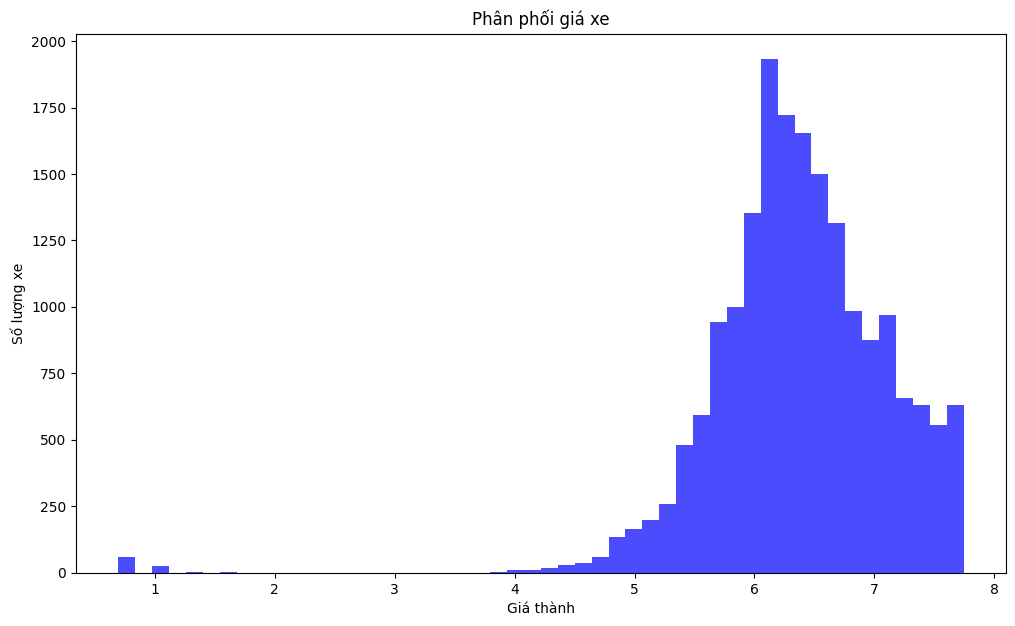

In [234]:
# vẽ biểu đồ phân phối giá
plt.figure(figsize=(12, 7))
plt.hist(data_clean['Giá thành'], bins=50, color='blue', alpha=0.7)
plt.title('Phân phối giá xe')
plt.xlabel('Giá thành')
plt.ylabel('Số lượng xe')
plt.show()

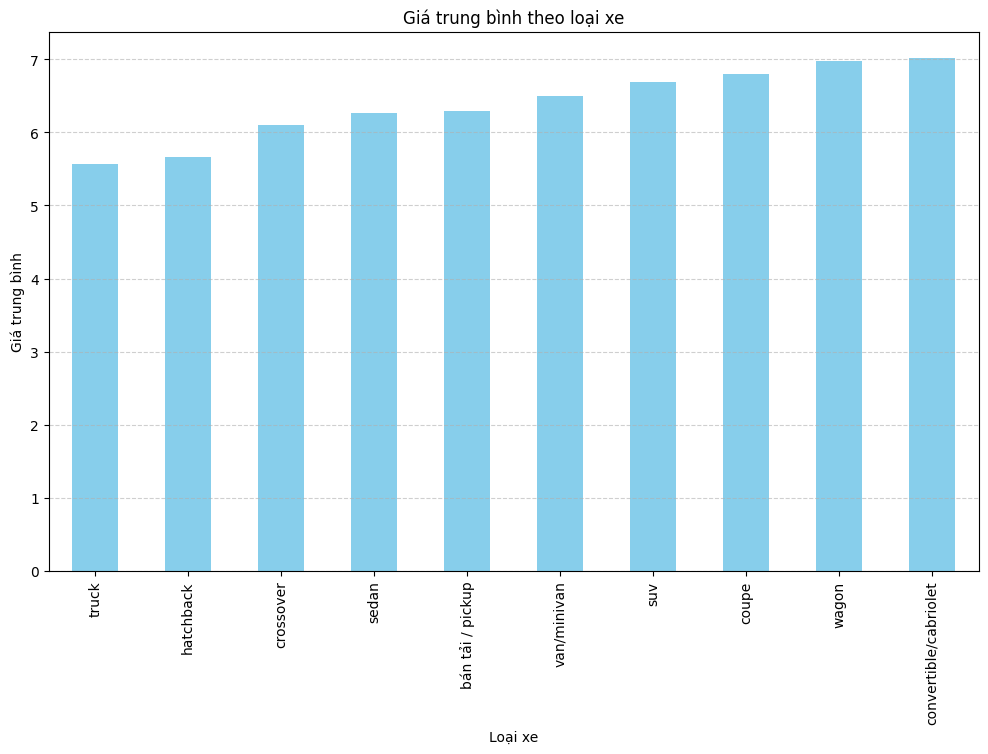

In [235]:
# Biểu đồ giá xe theo loại xe
plt.figure(figsize=(12, 7))
data_clean.groupby('Kiểu dáng')['Giá thành'].mean().sort_values().plot(kind='bar', color='skyblue')
plt.title('Giá trung bình theo loại xe')
plt.xlabel('Loại xe')
plt.ylabel('Giá trung bình')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

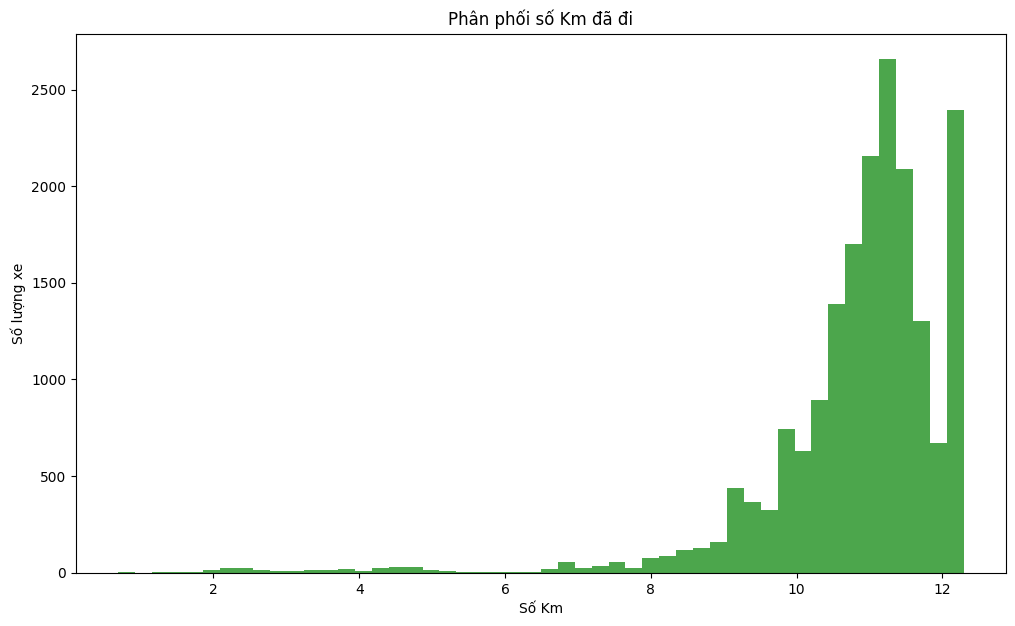

In [236]:
# biểu đồ phân phối số km đã đi
plt.figure(figsize=(12, 7))
plt.hist(data_clean['Số Km đã đi'], bins=50, color='green', alpha=0.7)
plt.title('Phân phối số Km đã đi')
plt.xlabel('Số Km')
plt.ylabel('Số lượng xe')
plt.show()

In [237]:
print(data_clean['Loại động cơ'].value_counts())
data_clean.to_csv("data_cleaned")

Loại động cơ
xăng      14964
dầu        3215
điện        463
hybrid      167
nan           1
Name: count, dtype: int64


Loại động cơ
xăng      14964
dầu        3215
điện        463
hybrid      167
nan           1
Name: count, dtype: int64


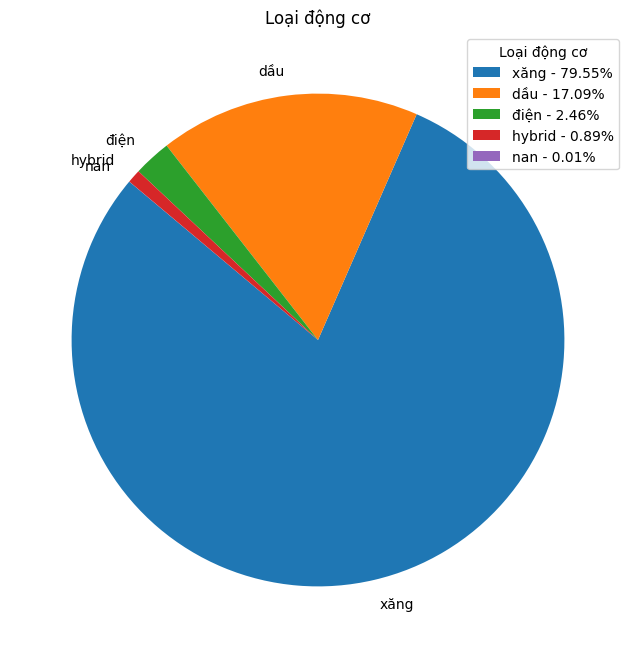

In [238]:
# biểu đồ tròn phân bố loại động cơ, không hiển thị phần trăm trên biểu đồ, hiện trên chú giải cả số %
engine_type_counts = data_clean['Loại động cơ'].value_counts()
print(engine_type_counts)
plt.figure(figsize=(10, 8))
plt.pie(engine_type_counts, labels=engine_type_counts.index, startangle=140)
plt.title('Loại động cơ')
plt.legend(title='Loại động cơ', loc='upper right', labels=[f"{i} - {j/engine_type_counts.sum()*100:.2f}%" for i, j in zip(engine_type_counts.index, engine_type_counts)])
plt.show()

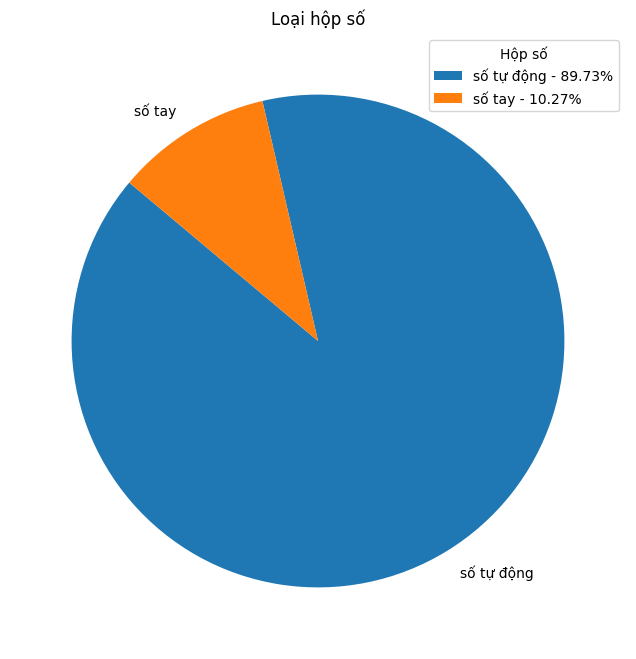

In [239]:
# biểu đồ tròn phân bố hộp số
transmission_type_counts = data_clean['Hộp số'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(transmission_type_counts, labels=transmission_type_counts.index, startangle=140)
plt.title('Loại hộp số')
plt.legend(title='Hộp số', loc='upper right', labels=[f"{i} - {j/transmission_type_counts.sum()*100:.2f}%" for i, j in zip(transmission_type_counts.index, transmission_type_counts)])
plt.show()

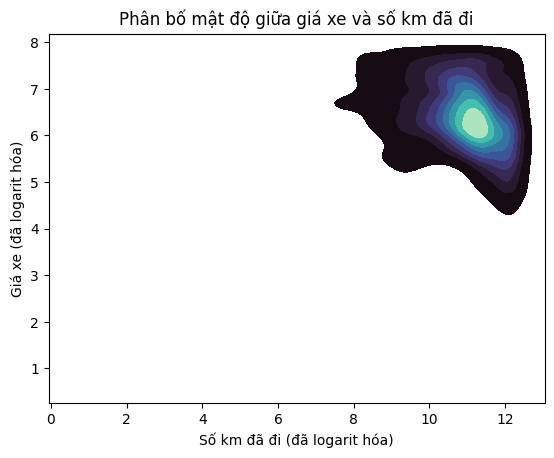

In [ ]:
import seaborn as sns
sns.kdeplot(
    x='Số Km đã đi',
    y='Giá thành',
    data=data_clean,
    fill=True,
    cmap='mako',
    thresh=0.05
)
plt.title('Phân bố mật độ giữa giá xe và số km đã đi')
plt.xlabel('Số km đã đi (đã logarit hóa)')
plt.ylabel('Giá xe (đã logarit hóa)')
plt.show()